# Tesla Stock Time Series Analysis

/tmp/ipykernel_1431/2242390265.py:17: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 734k/734k [00:00<00:00, 4.15MB/s]


First 5 Records:
         date       open       high       low      close    volume      rsi_7  \
0  2014-01-02   9.986667  10.165333  9.770000  10.006667  92826000  55.344071   
1  2014-01-03  10.000000  10.146000  9.906667   9.970667  70425000  53.742629   
2  2014-01-06  10.000000  10.026667  9.682667   9.800000  80416500  46.328174   
3  2014-01-07   9.841333  10.026667  9.683333   9.957333  75511500  53.263037   
4  2014-01-08   9.923333  10.246667  9.917333  10.085333  92448000  58.368660   

      rsi_14       cci_7     cci_14    sma_50    ema_50    sma_100   ema_100  \
0  54.440118  -37.373644  15.213422  9.682107  9.820167  10.494240  9.674284   
1  53.821521  -81.304471  17.481130  9.652800  9.826069  10.495693  9.680190   
2  50.870410 -123.427544 -37.824708  9.629467  9.825047  10.496740  9.682577   
3  53.406750  -84.784651 -20.779431  9.597747  9.830235  10.503407  9.688051   
4  55.423026   60.799662  43.570559  9.573240  9.840239  10.511147  9.695964   

       macd  bo

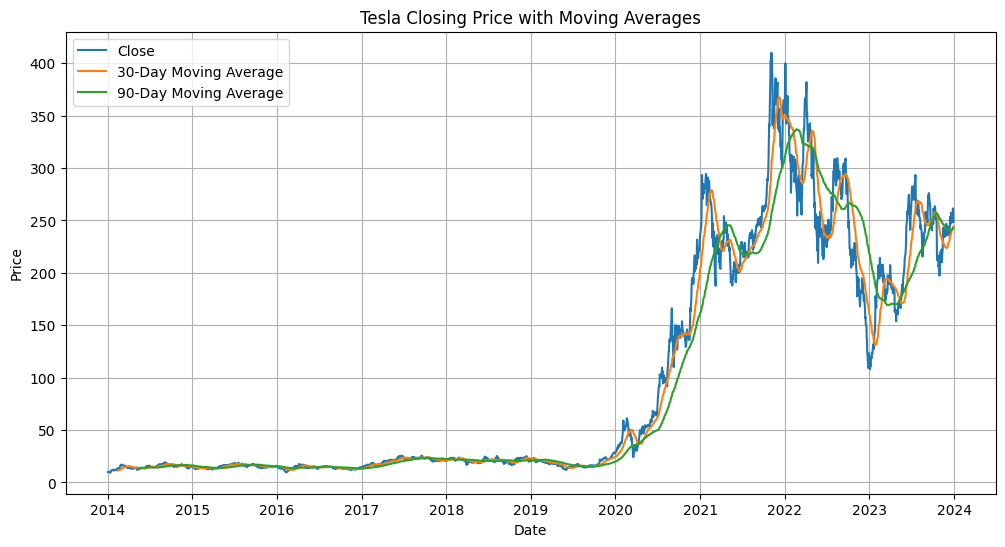

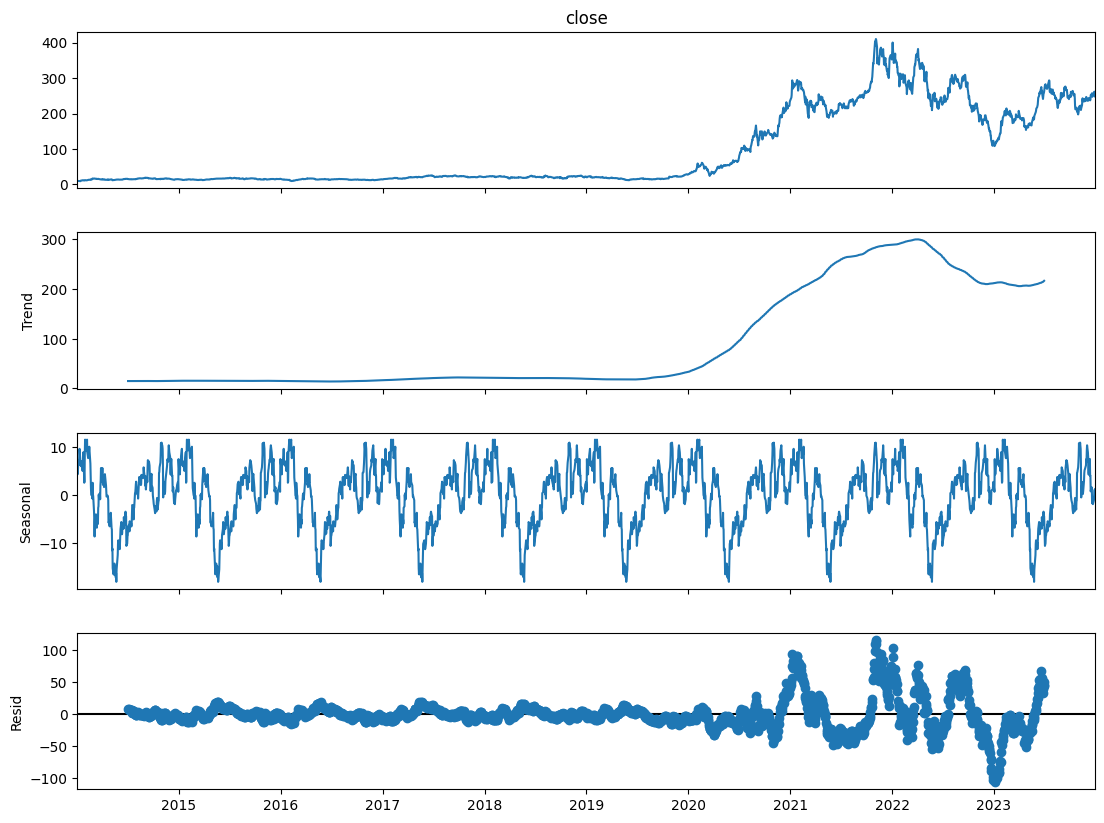

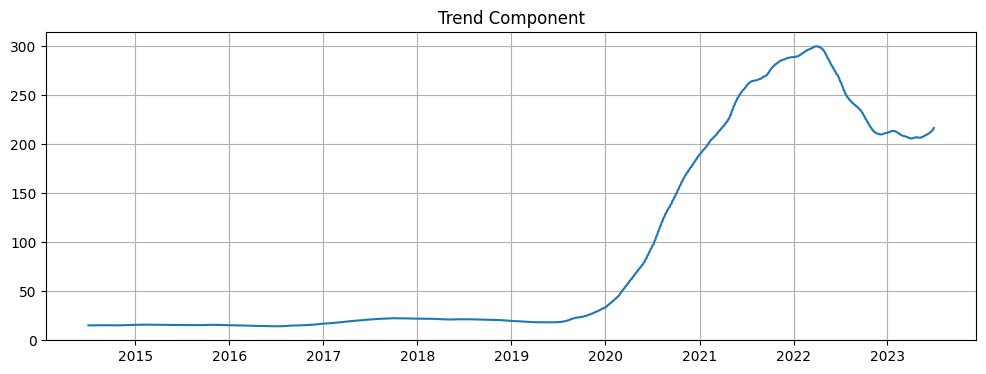

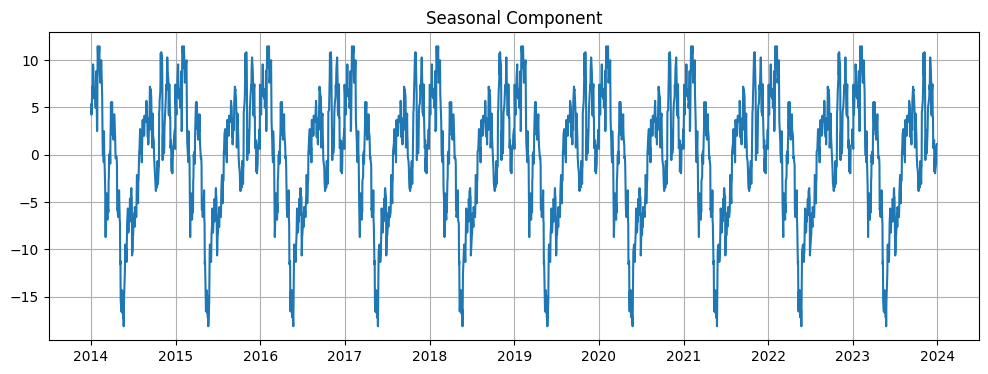

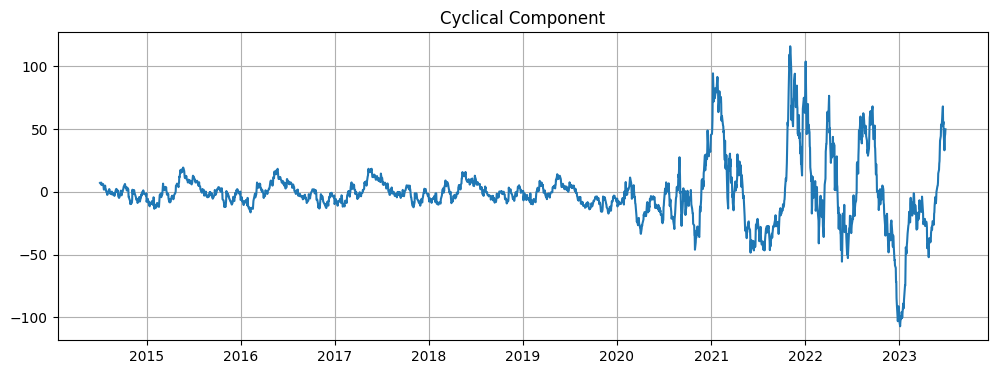

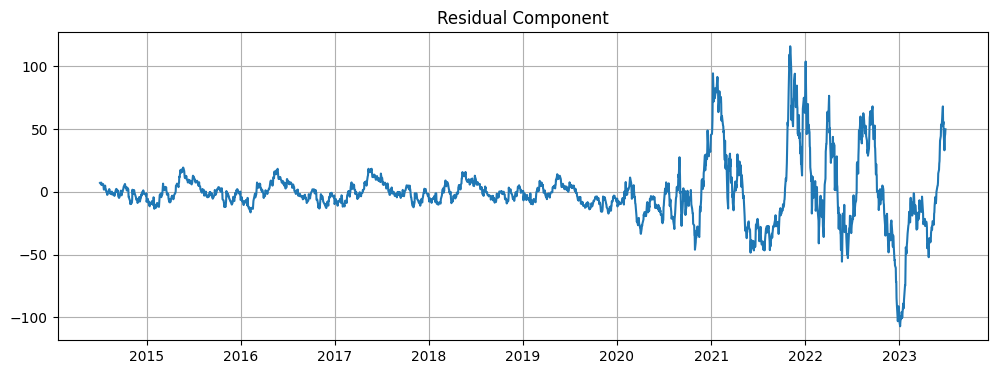

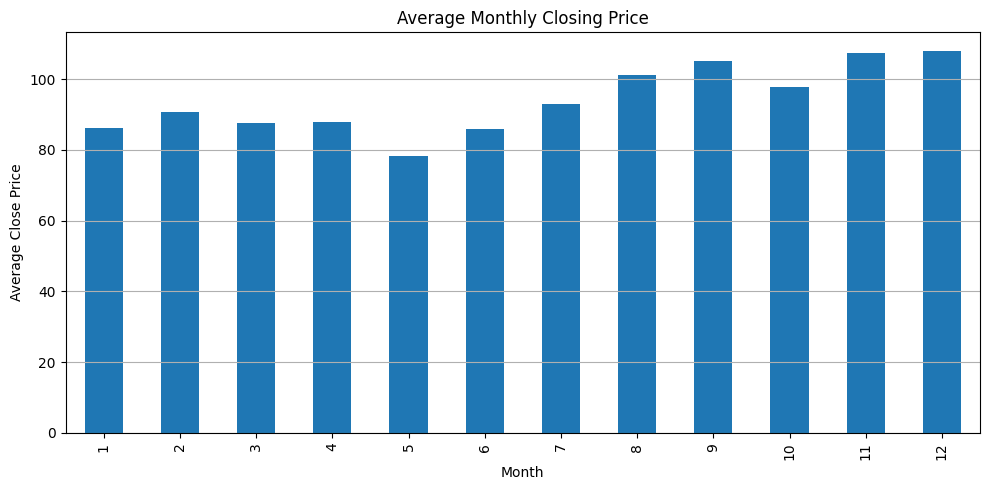


===== INTERPRETATION =====
- Trend: Observe the long-term movement from trend_component.png
- Seasonality: Observe recurring patterns from seasonal_component.png
- Cyclical: Observe medium- and long-term fluctuations from cyclical_component.png
- Residual: Random variations remaining after removing trend and seasonality.

Generated Files:
- trend_analysis.png
- time_series_decomposition.png
- trend_component.png
- seasonal_component.png
- cyclical_component.png
- residual_component.png
- monthly_average.png


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]

import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
# Replace this with the correct filename inside the dataset if necessary.
file_path = "tsla_2014_2023.csv"

# Load the latest version
df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "aspillai/tesla-stock-price-with-indicators-10-years",
    file_path,
    # Provide any additional arguments like
    # sql_query or pandas_kwargs. See the documentation:
    # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 Records:")
print(df.head())

# -----------------------------
# Data Preprocessing
# -----------------------------

date_col = next((c for c in df.columns if c.lower() == "date"), None)

if date_col is None:
    raise ValueError("Dataset must contain a Date column")

df[date_col] = pd.to_datetime(df[date_col])
df = df.sort_values(date_col)
df.set_index(date_col, inplace=True)

close_col = next(
    (c for c in df.columns if c.lower().replace(" ", "") in ["close", "adjclose"]),
    None,
)

if close_col is None:
    raise ValueError("Dataset must contain Close or Adj Close column")

print("\n===== DATA INFO =====")
print(df.info())

print("\n===== SUMMARY =====")
print(df.describe())

print("\n===== MISSING VALUES =====")
print(df.isnull().sum())

# -----------------------------
# Trend Analysis
# -----------------------------

series = df[close_col].dropna()

df["MA30"] = series.rolling(window=30).mean()
df["MA90"] = series.rolling(window=90).mean()

plt.figure(figsize=(12, 6))
plt.plot(series, label="Close")
plt.plot(df["MA30"], label="30-Day Moving Average")
plt.plot(df["MA90"], label="90-Day Moving Average")
plt.title("Tesla Closing Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.savefig("trend_analysis.png", dpi=300)
plt.show()

# -----------------------------
# Time Series Decomposition
# -----------------------------

period = 252 if len(series) > 500 else max(7, min(30, len(series) // 10))

decomposition = seasonal_decompose(
    series,
    model="additive",
    period=period
)

fig = decomposition.plot()
fig.set_size_inches(12, 9)
plt.savefig("time_series_decomposition.png", dpi=300)
plt.show()

trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid
cyclical = series - trend - seasonal

# -----------------------------
# Component Plots
# -----------------------------

plots = [
    (trend, "Trend Component", "trend_component.png"),
    (seasonal, "Seasonal Component", "seasonal_component.png"),
    (cyclical, "Cyclical Component", "cyclical_component.png"),
    (residual, "Residual Component", "residual_component.png"),
]

for data, title, filename in plots:
    plt.figure(figsize=(12, 4))
    plt.plot(data)
    plt.title(title)
    plt.grid(True)
    plt.savefig(filename, dpi=300)
    plt.show()

# -----------------------------
# Monthly Average Analysis
# -----------------------------

monthly = series.groupby(series.index.month).mean()

plt.figure(figsize=(10, 5))
monthly.plot(kind="bar")
plt.title("Average Monthly Closing Price")
plt.xlabel("Month")
plt.ylabel("Average Close Price")
plt.grid(axis="y")
plt.tight_layout()
plt.savefig("monthly_average.png", dpi=300)
plt.show()

# -----------------------------
# Interpretation
# -----------------------------

print("\n===== INTERPRETATION =====")
print("- Trend: Observe the long-term movement from trend_component.png")
print("- Seasonality: Observe recurring patterns from seasonal_component.png")
print("- Cyclical: Observe medium- and long-term fluctuations from cyclical_component.png")
print("- Residual: Random variations remaining after removing trend and seasonality.")

print("\nGenerated Files:")
files = [
    "trend_analysis.png",
    "time_series_decomposition.png",
    "trend_component.png",
    "seasonal_component.png",
    "cyclical_component.png",
    "residual_component.png",
    "monthly_average.png",
]

for file in files:
    print("-", file)

Using Colab cache for faster access to the 'tata-motors-stock-dataset-10-years' dataset.
Dataset Path: /kaggle/input/tata-motors-stock-dataset-10-years
['tata_motors.csv']
                  Open        High         Low       Close   Adj Close  \
Date                                                                     
2014-01-20  367.112366  372.751862  366.568176  370.921509  368.046509   
2014-01-21  371.020447  383.684601  368.250153  380.716431  377.765533   
2014-01-22  377.401978  383.387787  376.016846  382.002625  379.041748   
2014-01-23  381.161652  384.871857  376.659943  379.529175  376.587463   
2014-01-24  374.977997  377.995605  364.886230  366.469238  363.628784   

             Volume  
Date                 
2014-01-20  3246922  
2014-01-21  5781491  
2014-01-22  5654756  
2014-01-23  3790225  
2014-01-24  3620342  


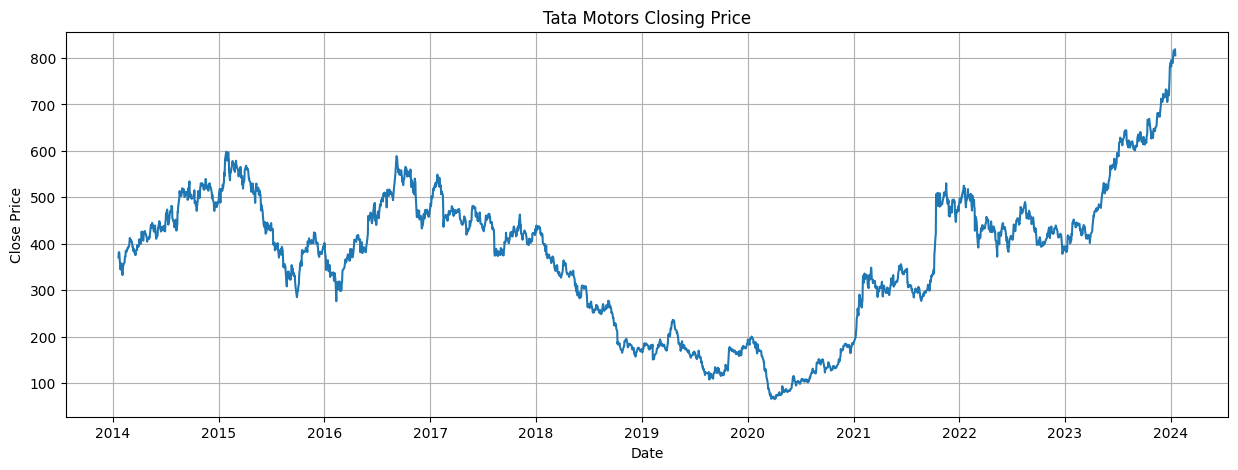

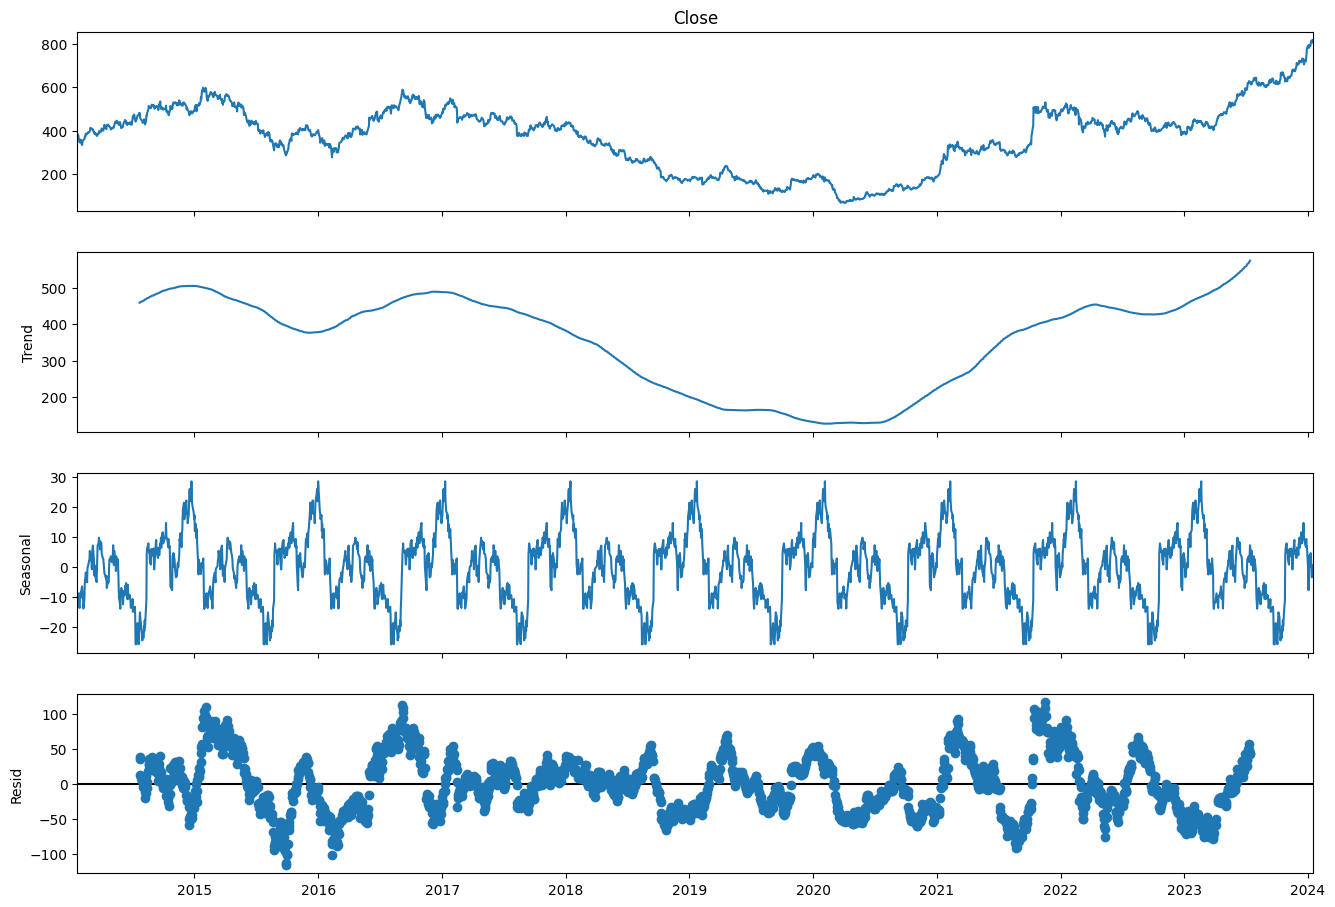

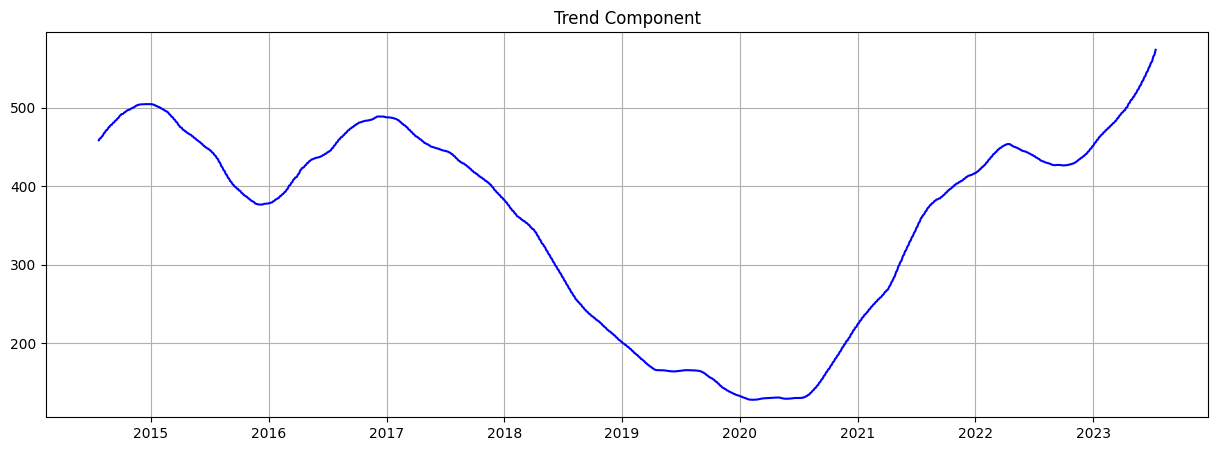

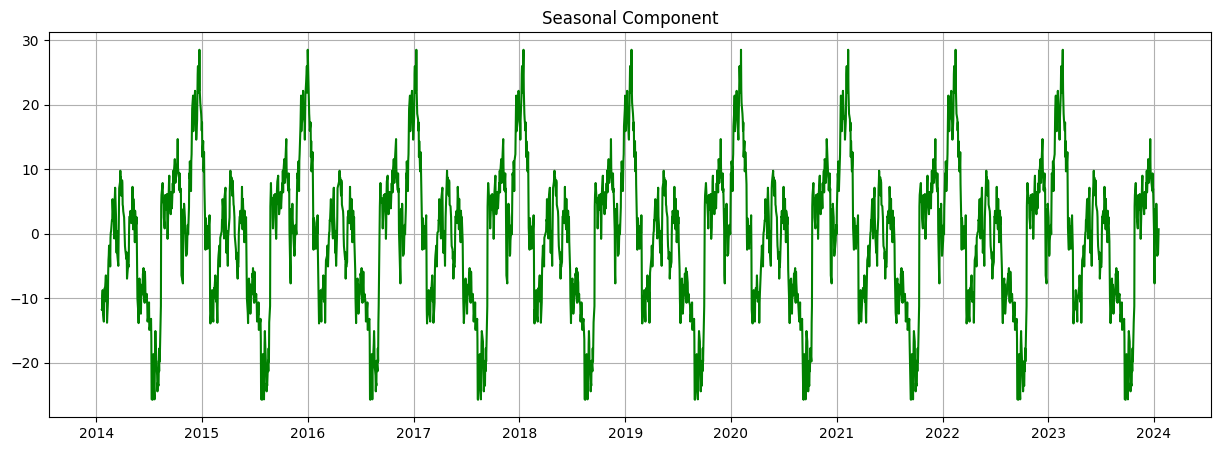

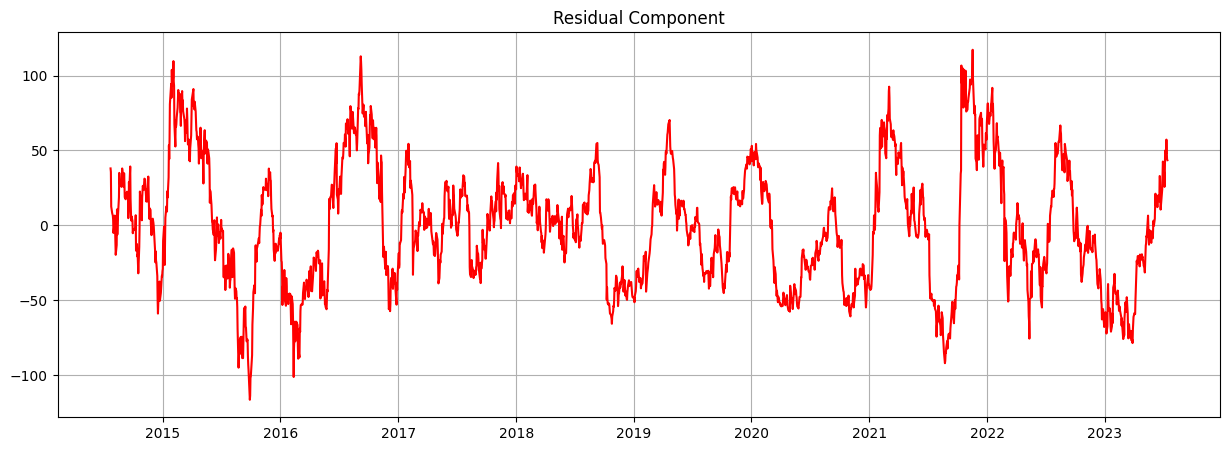

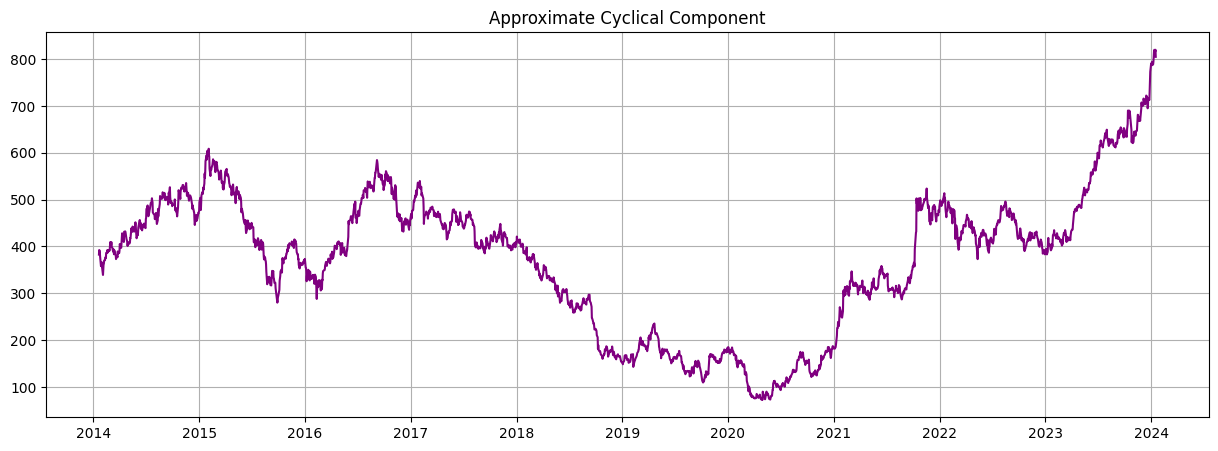

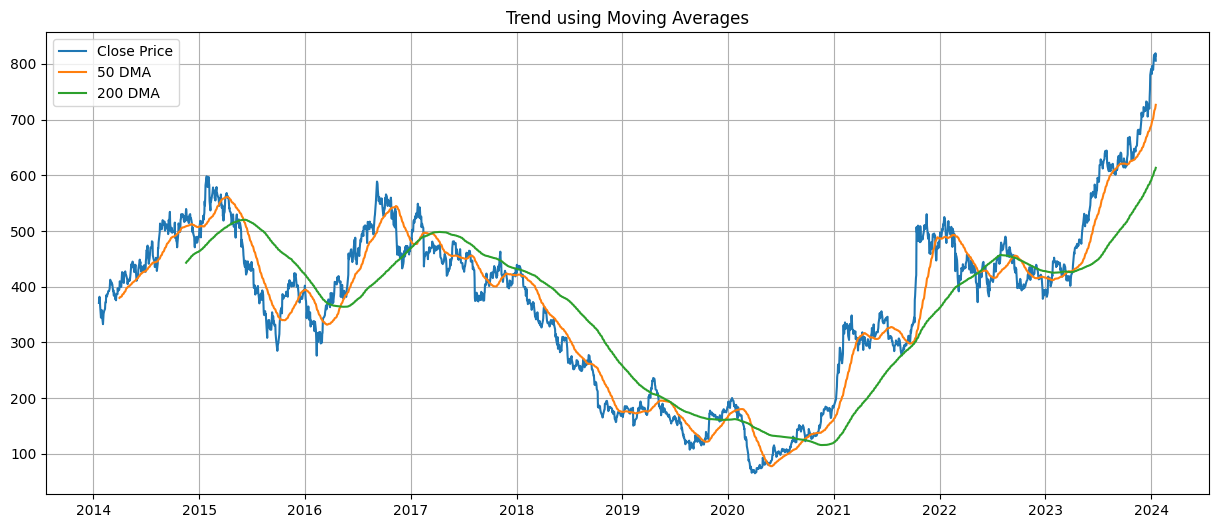

In [8]:
import kagglehub
import os
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# -----------------------------
# Download Dataset
# -----------------------------
path = kagglehub.dataset_download("divanshu22/tata-motors-stock-dataset-10-years")
print("Dataset Path:", path)

# Find CSV file
csv_files = [f for f in os.listdir(path) if f.endswith(".csv")]
print(csv_files)

df = pd.read_csv(os.path.join(path, csv_files[0]))

# -----------------------------
# Data Preparation
# -----------------------------
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df.set_index('Date', inplace=True)

print(df.head())

# -----------------------------
# Time Series
# -----------------------------
ts = df['Close']

plt.figure(figsize=(15,5))
plt.plot(ts)
plt.title("Tata Motors Closing Price")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.grid(True)
plt.show()

# =====================================================
# Trend + Seasonal + Residual Decomposition
# =====================================================
# 252 = Approx. trading days in one year

decomposition = seasonal_decompose(
    ts,
    model='additive',
    period=252
)

fig = decomposition.plot()
fig.set_size_inches(15,10)
plt.show()

# =====================================================
# Individual Components
# =====================================================

# Trend
plt.figure(figsize=(15,5))
plt.plot(decomposition.trend,color='blue')
plt.title("Trend Component")
plt.grid(True)
plt.show()

# Seasonal
plt.figure(figsize=(15,5))
plt.plot(decomposition.seasonal,color='green')
plt.title("Seasonal Component")
plt.grid(True)
plt.show()

# Residual
plt.figure(figsize=(15,5))
plt.plot(decomposition.resid,color='red')
plt.title("Residual Component")
plt.grid(True)
plt.show()

# =====================================================
# Cyclical Component
# Cyclical = Trend + Residual (Approximation)
# =====================================================

cyclical = ts - decomposition.seasonal

plt.figure(figsize=(15,5))
plt.plot(cyclical,color='purple')
plt.title("Approximate Cyclical Component")
plt.grid(True)
plt.show()

# =====================================================
# Moving Average Trend
# =====================================================

df['50DMA'] = ts.rolling(50).mean()
df['200DMA'] = ts.rolling(200).mean()

plt.figure(figsize=(15,6))
plt.plot(ts,label='Close Price')
plt.plot(df['50DMA'],label='50 DMA')
plt.plot(df['200DMA'],label='200 DMA')
plt.title("Trend using Moving Averages")
plt.legend()
plt.grid(True)
plt.show()

/tmp/ipykernel_1431/1604952726.py:17: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'hdfc-stock-dataset-2024' dataset.
   Unnamed: 0  Symbol Series         Date PrevClose OpenPrice HighPrice  \
0           0     NaN     EQ  01-Jun-2022  1,388.95  1,380.00  1,400.45   
1           1     NaN     EQ  02-Jun-2022  1,394.85  1,387.25  1,388.00   
2           2     NaN     EQ  03-Jun-2022  1,385.10  1,398.30  1,400.75   
3           3     NaN     EQ  06-Jun-2022  1,380.30  1,376.30  1,387.00   
4           4     NaN     EQ  07-Jun-2022  1,378.45  1,362.00  1,374.30   

   LowPrice LastPrice ClosePrice AveragePrice TotalTradedQuantity  \
0  1,379.15  1,396.10   1,394.85     1,391.06           60,45,948   
1  1,378.60  1,385.20   1,385.10     1,383.53           57,37,510   
2  1,376.30  1,379.00   1,380.30     1,388.75           34,78,622   
3  1,360.65  1,377.00   1,378.45     1,380.25           30,86,633   
4  1,354.10  1,362.15   1,362.60     1,362.41           51,26,983   

        TurnoverInRs No.ofTrades DeliverableQty %DlyQtto

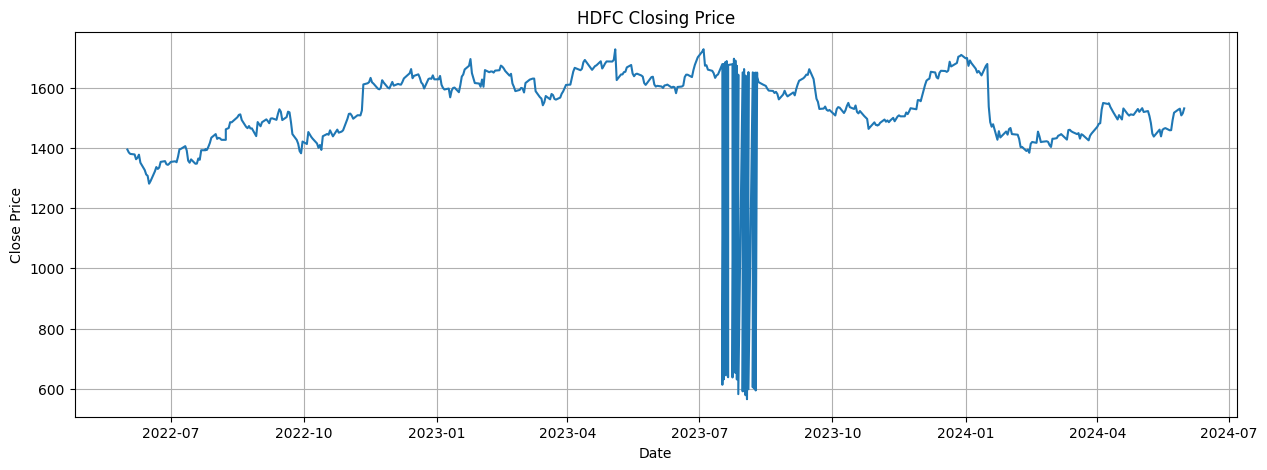

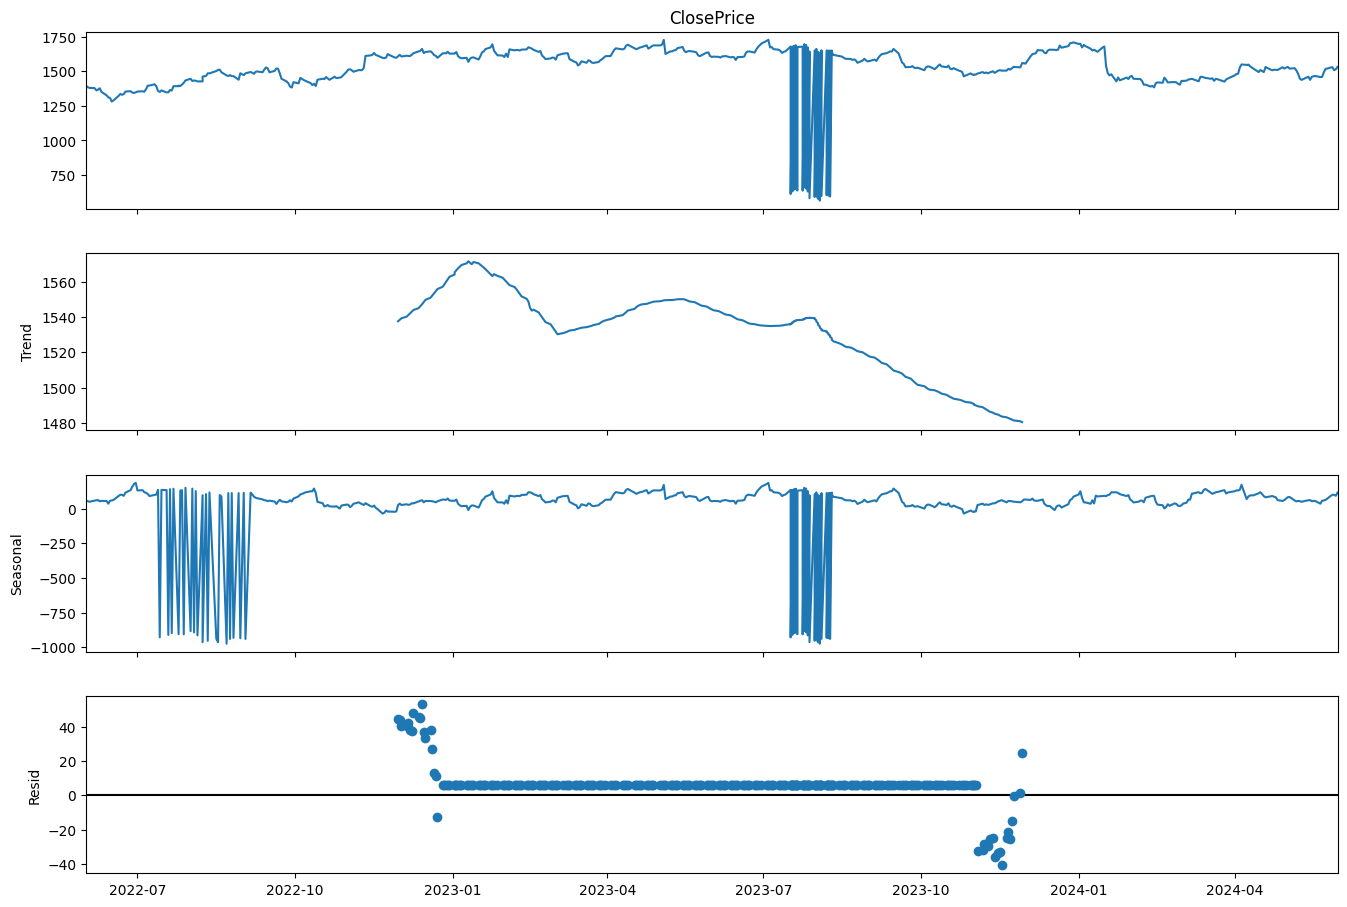

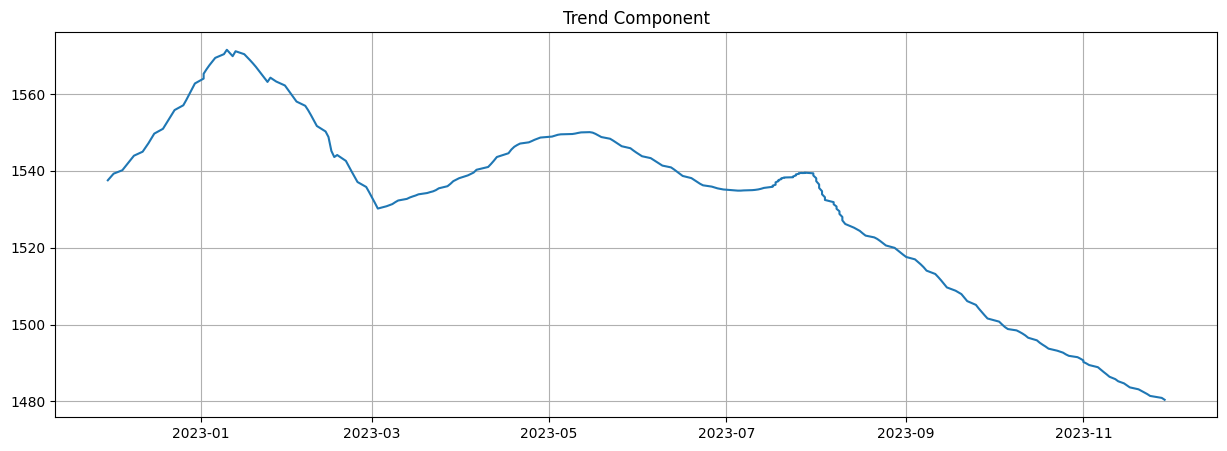

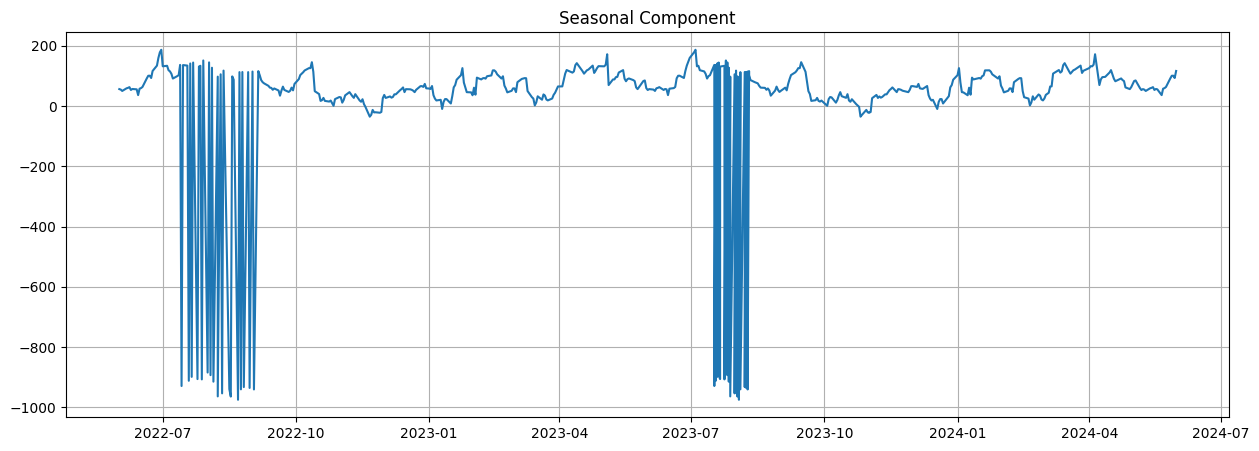

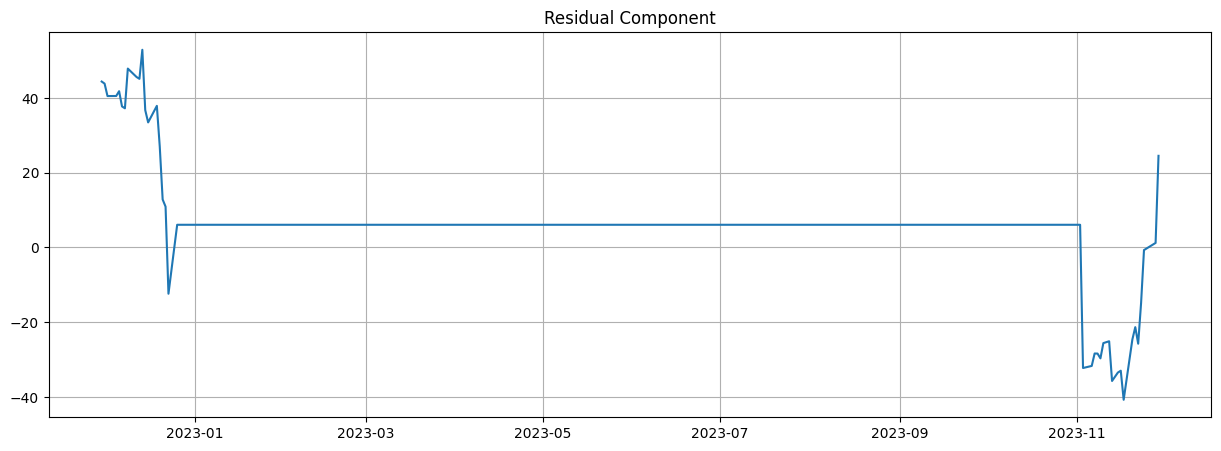

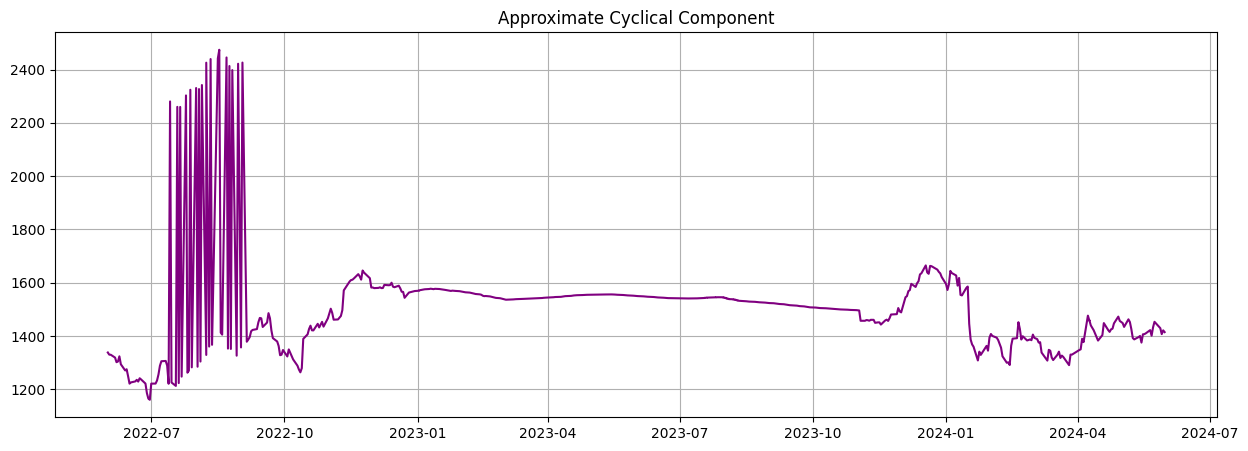

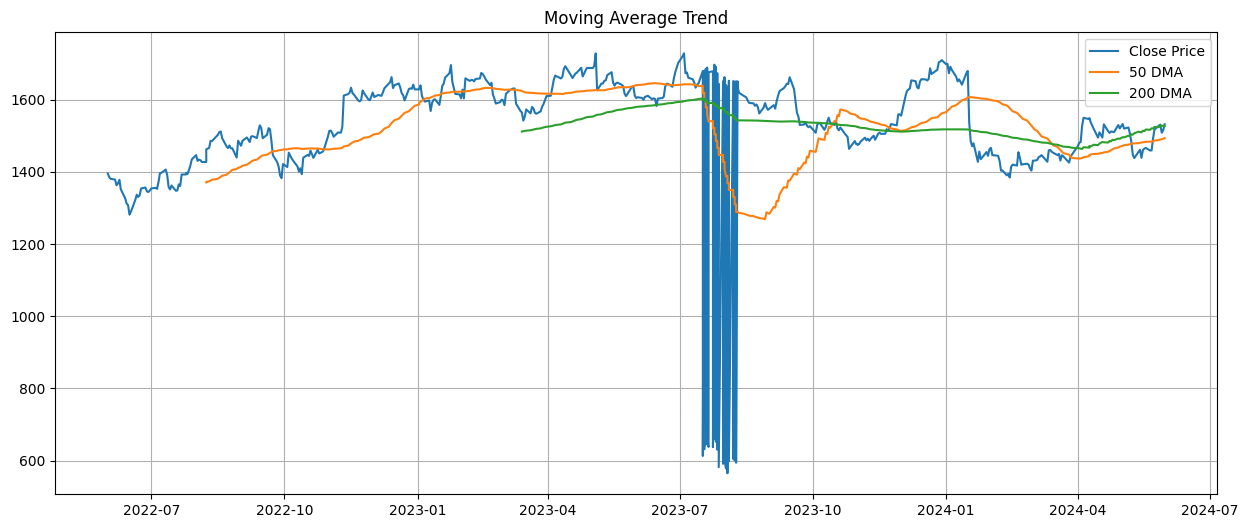

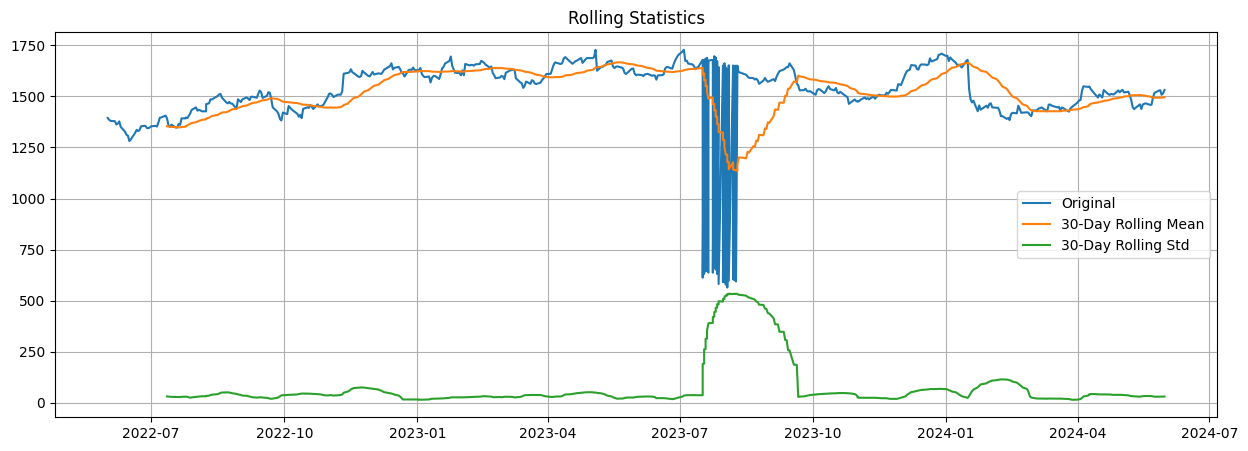

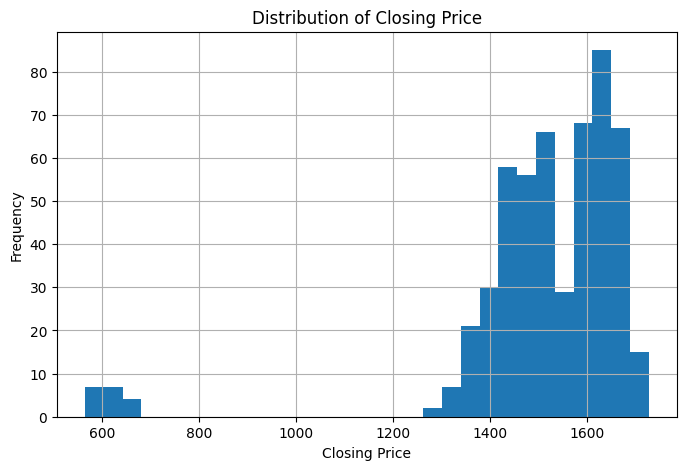

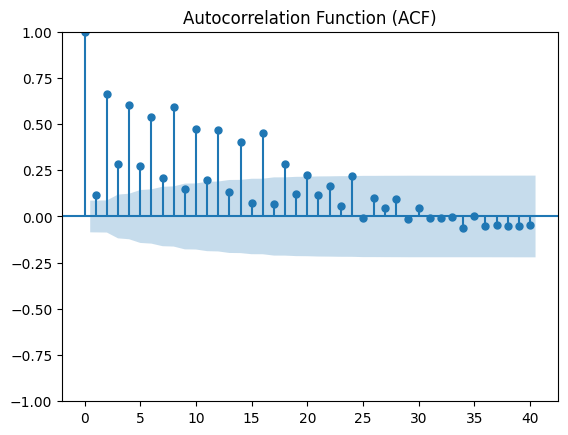

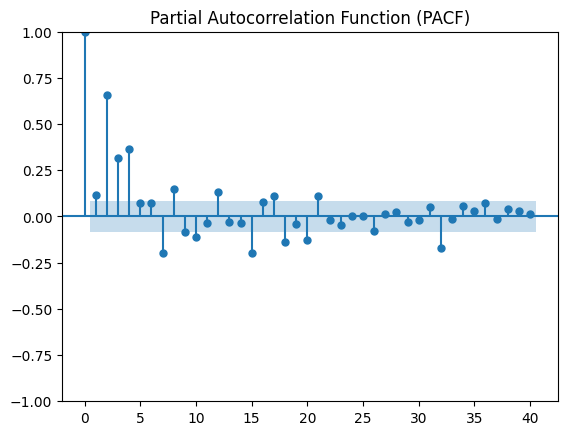

KeyError: "['Turnover'] not in index"

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import kagglehub
from kagglehub import KaggleDatasetAdapter

# ============================================
# Load Dataset
# ============================================

file_path = "HDFCBANK.csv"

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "sukritsingh/hdfc-stock-dataset-2024",
    file_path
)

print(df.head())

# ============================================
# Data Preprocessing
# ============================================

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df.set_index('Date', inplace=True)

# Clean and convert 'ClosePrice' to numeric
df['ClosePrice'] = df['ClosePrice'].str.replace(',', '').astype(float)

# Use Closing Price
close = df['ClosePrice']

print(df.info())
print(df.describe())

# ============================================
# Original Time Series
# ============================================

plt.figure(figsize=(15,5))
plt.plot(close)
plt.title("HDFC Closing Price")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.grid(True)
plt.show()

# ============================================
# Trend, Seasonal & Residual Analysis
# ============================================

decompose = seasonal_decompose(
    close,
    model='additive',
    period=252
)

fig = decompose.plot()
fig.set_size_inches(15,10)
plt.show()

# ============================================
# Trend Component
# ============================================

plt.figure(figsize=(15,5))
plt.plot(decompose.trend)
plt.title("Trend Component")
plt.grid(True)
plt.show()

# ============================================
# Seasonal Component
# ============================================

plt.figure(figsize=(15,5))
plt.plot(decompose.seasonal)
plt.title("Seasonal Component")
plt.grid(True)
plt.show()

# ============================================
# Residual Component
# ============================================

plt.figure(figsize=(15,5))
plt.plot(decompose.resid)
plt.title("Residual Component")
plt.grid(True)
plt.show()

# ============================================
# Cyclical Component
# ============================================

cyclical = close - decompose.seasonal

plt.figure(figsize=(15,5))
plt.plot(cyclical,color='purple')
plt.title("Approximate Cyclical Component")
plt.grid(True)
plt.show()

# ============================================
# Moving Average Trend
# ============================================

df['50DMA'] = close.rolling(50).mean()
df['200DMA'] = close.rolling(200).mean()

plt.figure(figsize=(15,6))
plt.plot(close,label='Close Price')
plt.plot(df['50DMA'],label='50 DMA')
plt.plot(df['200DMA'],label='200 DMA')

plt.legend()
plt.title("Moving Average Trend")
plt.grid(True)
plt.show()

# ============================================
# Rolling Statistics
# ============================================

rolling_mean = close.rolling(30).mean()
rolling_std = close.rolling(30).std()

plt.figure(figsize=(15,5))
plt.plot(close,label='Original')
plt.plot(rolling_mean,label='30-Day Rolling Mean')
plt.plot(rolling_std,label='30-Day Rolling Std')

plt.legend()
plt.title("Rolling Statistics")
plt.grid(True)
plt.show()

# ============================================
# Distribution
# ============================================

plt.figure(figsize=(8,5))
plt.hist(close,bins=30)
plt.title("Distribution of Closing Price")
plt.xlabel("Closing Price")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

# ============================================
# ACF
# ============================================

plot_acf(close,lags=40)
plt.title("Autocorrelation Function (ACF)")
plt.show()

# ============================================
# PACF
# ============================================

plot_pacf(close,lags=40,method='ywm')
plt.title("Partial Autocorrelation Function (PACF)")
plt.show()

# ============================================
# Correlation Heatmap
# ============================================

numeric_cols = [
    'PrevClose','OpenPrice','HighPrice',
    'LowPrice','LastPrice','ClosePrice',
    'AveragePrice','TotalTradedQuantity',
    'Turnover','No.ofTrades','DeliverableQty'
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(10,8))
plt.imshow(corr, cmap='coolwarm', interpolation='nearest')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()